In [1]:
import numpy as np
import cupy as cp
import pandas as pd
from cupyx.scipy import ndimage
from tanalysis import improcess
import matplotlib.pyplot as plt
import tifffile as tiff
from skimage.measure import label, regionprops, regionprops_table
from skimage import exposure, morphology

In [54]:
def LoG(sigma_x, sigma_y, sigma_z):
    #n = cp.ceil(max(sigma_x, sigma_y, sigma_z)*6)
    n = 7
    z,y,x = cp.ogrid[-n//2:n//2+1, -n//2:n//2+1, -n//2:n//2+1]
    z_filter = cp.exp(-(z*z/(2*sigma_z**2)))
    y_filter = cp.exp(-(y*y/(2*sigma_y**2)))
    x_filter = cp.exp(-(x*x/(2*sigma_x**2)))
    final_filter = (1/(sigma_x*sigma_y*sigma_z*(2*np.pi)**(3/2)))*((1-x*x/(sigma_x**2))/(sigma_x**2)+(1-y*y/(sigma_y**2))/(sigma_y**2)+(1-z*z/(sigma_z**2))/(sigma_z**2))*(z_filter*x_filter*y_filter)
    return final_filter

In [ ]:
def LoG_convolve(img, sigmas_x, sigma_y, sigma_z):
    filter_log = LoG(sigmas_x, sigma_y, sigma_z)
    image = ndimage.convolve(img, filter_log)
    #image = cp.pad(image, ((1,1,1),(1,1,1)), 'constant')
    image = cp.square(image)
    return cp.asarray(image)

In [ ]:
def fit_gaussian(sigma_x, sigma_y, sigma_z):
    n = 7
    z,y,x = cp.ogrid[-n//2:n//2+1, -n//2:n//2+1, -n//2:n//2+1]
    z_filter = cp.exp(-(z*z/(2*sigma_z**2)))
    y_filter = cp.exp(-(y*y/(2*sigma_y**2)))
    x_filter = cp.exp(-(x*x/(2*sigma_x**2)))
    final_filter = (x_filter*y_filter*z_filter)/(sigma_x*sigma_y*sigma_z*(2*np.pi)**(3/2))
    return final_filter

In [8]:
dirname = r"C:\Users\pcanaleta\Documents\Img_Processing\Chips\Originals\24h_chem10.tif"
imgs, names, info = improcess.imread(dirname, False, False)

In [ ]:
def label_cells(image:np.ndarray, sigmas:list):
    ''' 
    '''
    Z,Y,X = image.shape
    og_img = np.double(image)
    img = cp.array(og_img)

    gaussian = fit_gaussian(*sigmas)
    img = ndimage.convolve(img, gaussian)
    th1 = cp.max(img)*0.1 #####################
    img_th1 = img>th1

    img = LoG_convolve(img, *sigmas)
    th2 = cp.max(img)*0.1 #####################
    img_th2 = img>th2

In [ ]:
Z,Y,X = imgs[0].shape
result = np.empty(shape=(Z,Y,X), dtype=np.int8)
sigmas = (5,5,1)
og_img = np.float16(imgs[0]) # original image
img = cp.array(og_img)

gaussian = fit_gaussian(*sigmas)
img = ndimage.convolve(img, gaussian)
th1 = cp.max(img)*0.1
img_th1 = img>th1

img = LoG_convolve(img, sigmas)
th2 = cp.max(img)*0.1
img_th2 = img>th2

img_th1 = cp.asnumpy(img_th1)
img_th2 = cp.asnumpy(img_th2)

img_r1 = np.uint8(255*img_th1)-np.uint8(255*img_th2)
img = morphology.dilation(img_r1)
img = morphology.erosion(img)
img = morphology.remove_small_holes(img)
img_r1 = morphology.remove_small_objects(img) #######

img = cp.asarray(np.float16(img_r1)) ########
img = LoG_convolve(img, sigmas)
img = cp.asnumpy(img)
th3 = np.max(img)*0.1
img_th3 = img>th3
img_r2 = img_r1 - np.uint8(255*img_th3)
img = morphology.erosion(img_r2)
img = morphology.remove_small_objects(img)
img = label(img)

c:\Users\pcanaleta\Documents\python_codes\venvs\tanalysis\Lib\site-packages\skimage\_shared\utils.py:386: UserWarning: Any labeled images will be returned as a boolean array. Did you mean to use a boolean array?
  return func(*args, **kwargs)


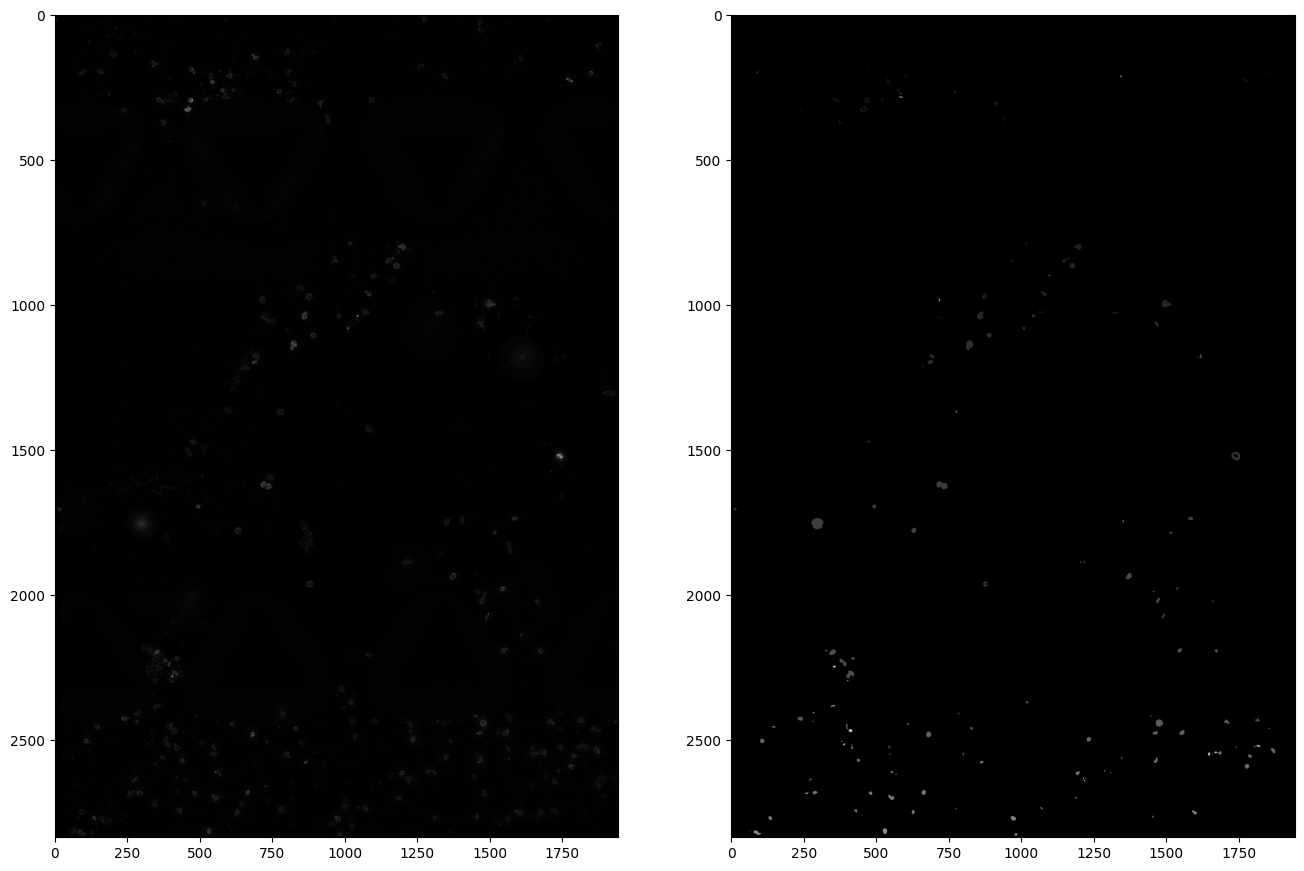

In [228]:
z = 4
fig, ax = plt.subplots(1, 2, figsize=(16,18))
ax[0].imshow(imgs[0][z], cmap='gray')
ax[1].imshow(img[z], cmap='gray')
plt.show()

In [217]:
result_img = img/np.max(img)
result_img = np.uint8(result_img*255)
tiff.imwrite(r"C:\Users\pcanaleta\Documents\Img_Processing\Chips\Processed\24h_chem10.tiff", 
            result_img, 
            imagej=True,
            metadata={
                'axes':"ZYX"
            })

In [7]:
T,D,H,W = imgs[0].shape
result = np.empty(shape=(T,D,H,W), dtype=np.int8)
t=0
for img in imgs[0]:
    kernel_size = (D, H//5, W//5)
    img = exposure.equalize_adapthist(img, kernel_size)
    th = cp.max(img)
    img = img>th*0.35
    img = morphology.dilation(img)
    img = morphology.erosion(img)
    img = morphology.remove_small_holes(img)
    img = morphology.remove_small_objects(img)
    img = label(img)
    result[t] = img
    t += 1

KeyboardInterrupt: 

In [49]:
img = imgs[0][0]
Z,Y,X = img.shape
#img_eq = exposure.equalize_hist(img)
kernel_size = (Z, X//5, Y//5) 
img_ad_eq = exposure.equalize_adapthist(img, kernel_size)

In [ ]:
th = np.max(img_ad_eq)
img_th = img_ad_eq>th*0.35
img_th_dil = morphology.dilation(img_th)
img_th_ero = morphology.erosion(img_th_dil)
img_th_rsh = morphology.remove_small_holes(img_th_ero)
img_th_rso = morphology.remove_small_objects(img_th_rsh)
img_lab = label(img_th_rso)

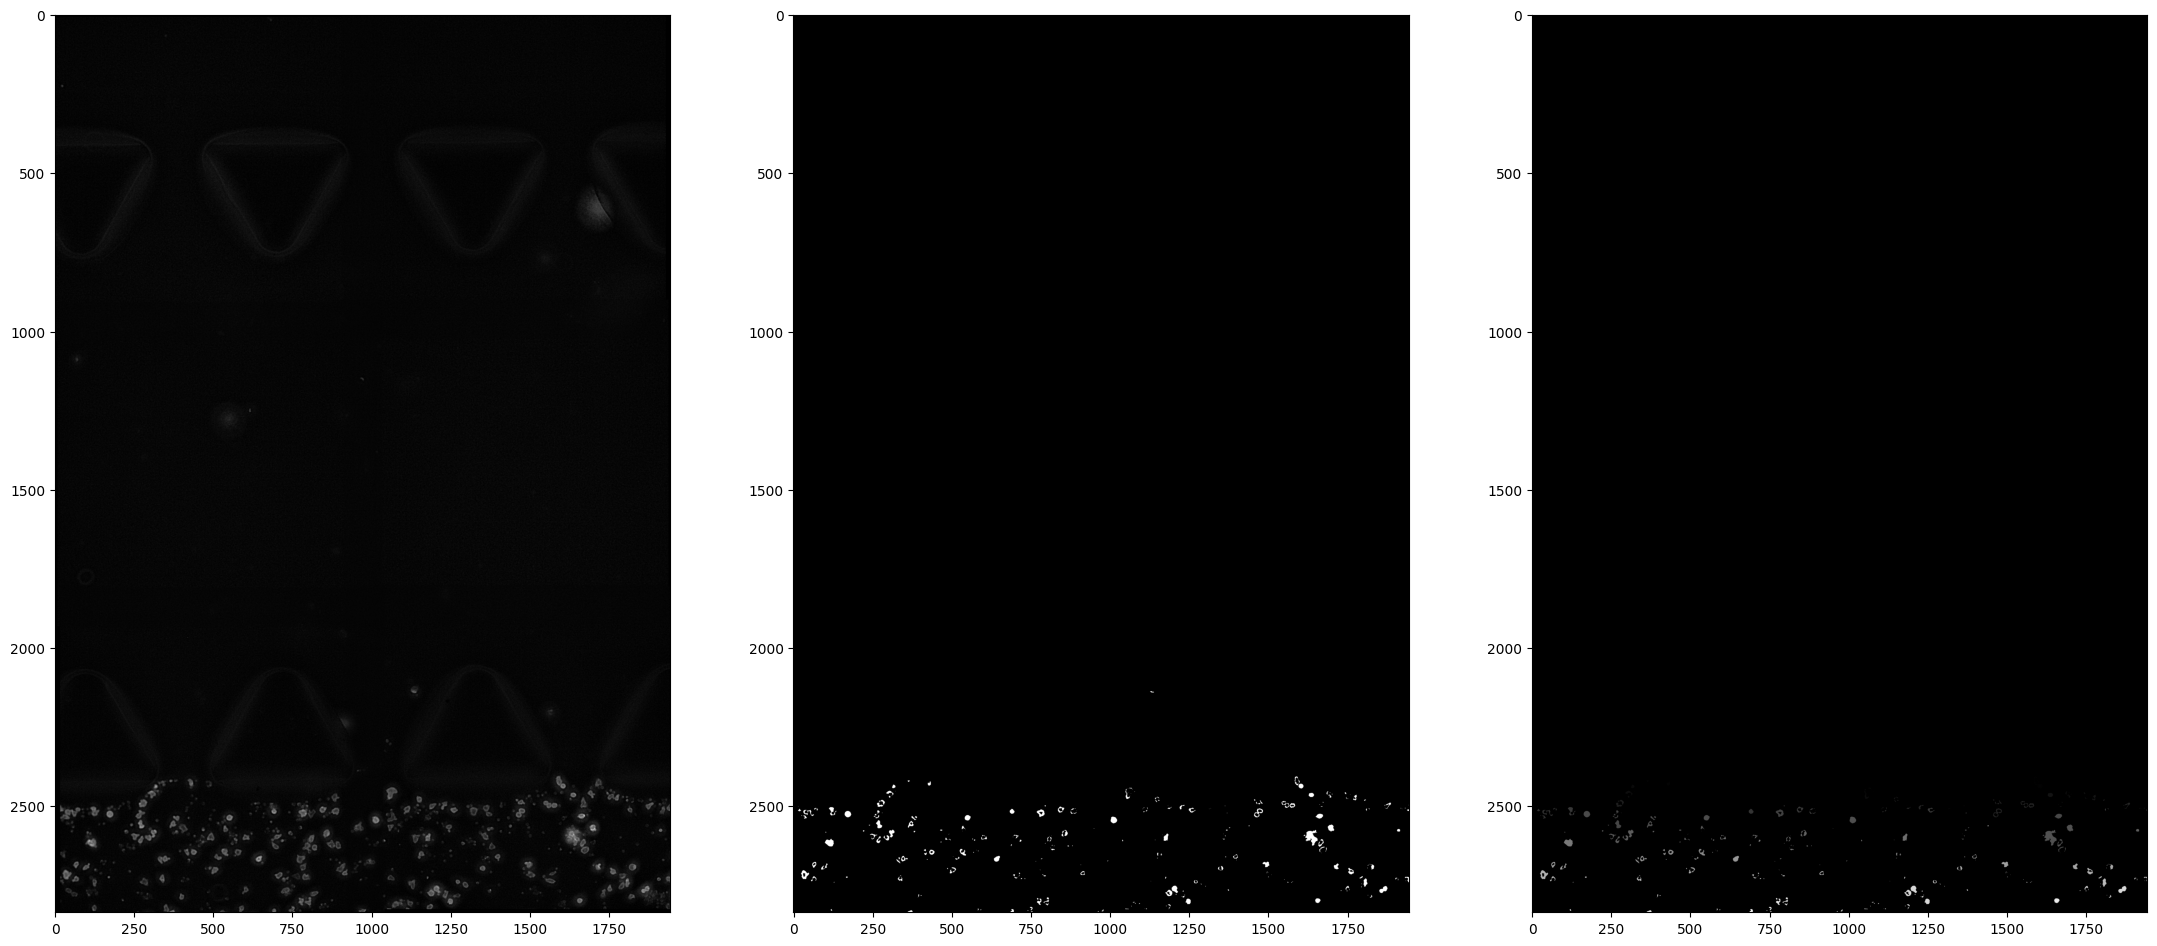

In [127]:
z = 4
fig, ax = plt.subplots(1,3, figsize=(27,16))
ax[0].imshow(img_ad_eq[z], cmap='gray')
ax[1].imshow(img_th_rso[z], cmap='gray')
ax[2].imshow(img_lab[z], cmap='gray')
plt.show()

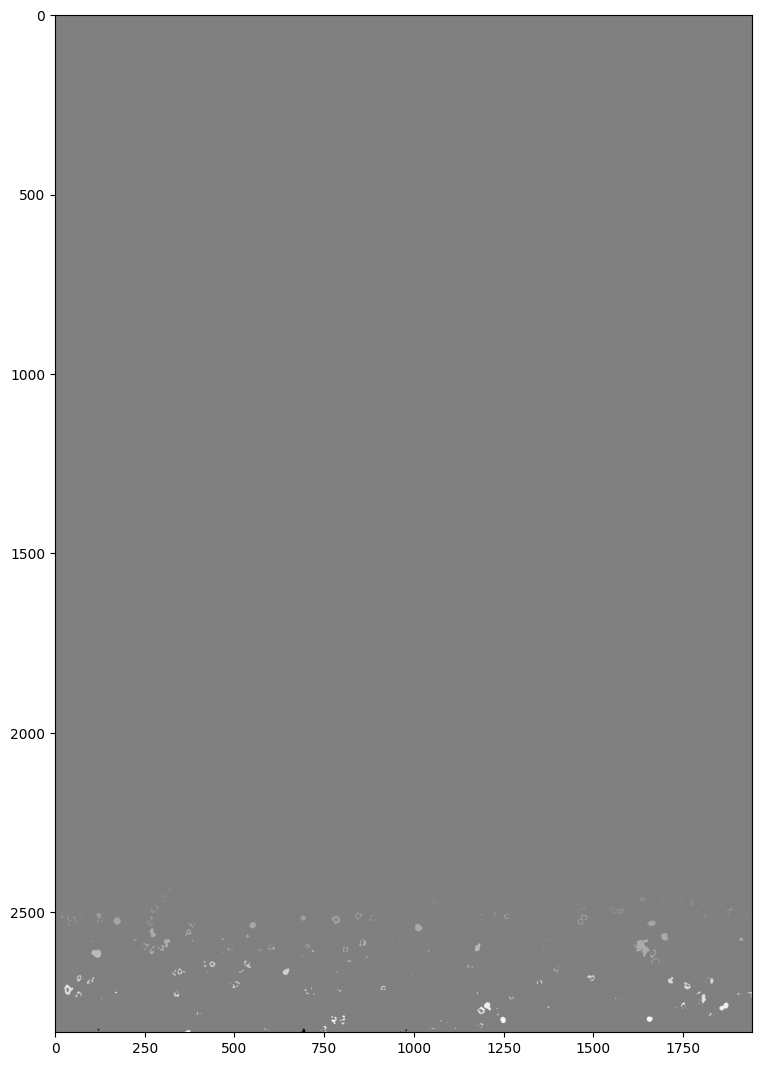

In [131]:
im = cp.asnumpy(result[0])

plt.figure(figsize=(9,16))
plt.imshow(im[4], cmap='gray')
plt.show()

In [132]:
result_img = cp.asnumpy(result)
result_img = 255*np.uint8(result_img)
tiff.imwrite(r"C:\Users\pcanaleta\Desktop\Test\test.tiff", 
            result_img, 
            imagej=True,
            metadata={
                'axes':"TZYX"
            })

c:\Users\pcanaleta\Documents\python_codes\venvs\tanalysis\Lib\site-packages\tifffile\tifffile.py:3721: UserWarning: <tifffile.TiffWriter 'test.tiff'> truncating ImageJ file
  self._write_remaining_pages()
